In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

In [ ]:
DATA_DIR = Path("../data") 


sheets = pd.read_excel(DATA_DIR / "online_retail_II.xlsx", sheet_name=None)
df = pd.concat(sheets.values(), ignore_index=True)

print(df.shape)


(1067371, 8)


In [3]:
df_raw = df.copy()

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.shape

(1067371, 8)

In [6]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [7]:
df.tail(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067361,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
1067362,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
1067363,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
1067364,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [8]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 266.5 MB


In [9]:
(df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False)

Customer ID    22.77
Description     0.41
Invoice         0.00
StockCode       0.00
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Country         0.00
dtype: float64

In [10]:
mask = df['Customer ID'].isnull()
df[mask]['Invoice'].astype(str).str.startswith('C').sum()

np.int64(750)

In [ ]:
unidentified = df[df['Customer ID'].isnull()]
print(unidentified['Price'].describe())        
print((unidentified['Quantity'] <= 0).sum())   
print(unidentified['Country'].value_counts().head())  

count    243007.000000
mean          7.948744
std         224.275451
min      -53594.360000
25%           1.660000
50%           3.290000
75%           5.790000
max       25111.090000
Name: Price, dtype: float64
4206
Country
United Kingdom    240029
EIRE                1671
Hong Kong            364
Unspecified          232
France               128
Name: count, dtype: int64


In [12]:
df[df['Customer ID'].isnull()][['Quantity','Price']].describe()

,Quantity,Price
count,243007.000000,243007.000000
mean,1.540548,7.948744
std,98.859370,224.275451
min,-9600.000000,-53594.360000
25%,1.000000,1.660000
50%,1.000000,3.290000
75%,2.000000,5.790000
max,10200.000000,25111.090000


In [ ]:
mask = df_raw['Description'].isnull()
df_raw[mask]['Customer ID'].isnull().mean()

np.float64(1.0)

In [14]:
valid_mask = df['Price'] > 0
df_rev = df[valid_mask].copy()
df_rev['Revenue'] = df_rev['Quantity'] * df_rev['Price']

total_revenue_all = df_rev['Revenue'].sum()
unidentified_revenue = df_rev.loc[df_rev['Customer ID'].isnull(), 'Revenue'].sum()
print(f"Share of net revenue from unidentified (guest-checkout) sales: {unidentified_revenue/total_revenue_all*100:.2f}%")
print(df_rev.loc[df_rev['Customer ID'].isnull(), 'Country'].value_counts(normalize=True).head() * 100)


Share of net revenue from unidentified (guest-checkout) sales: 14.39%
Country
United Kingdom    98.744042
EIRE               0.704181
Hong Kong          0.153670
Unspecified        0.097944
France             0.054038
Name: proportion, dtype: float64


In [ ]:
before = df.shape[0]
df = df[df['Customer ID'].notnull()].copy()
df['Customer ID'] = df['Customer ID'].astype('Int64') 
print(before, '->', df.shape[0])


1067371 -> 824364


In [16]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [17]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [18]:
df['Quantity'].describe()

count    824364.000000
mean         12.414574
std         188.976099
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [19]:
(df['Quantity'] < 0).sum()

np.int64(18744)

In [20]:
(df['Price'] <0).sum()

np.int64(0)

In [21]:
(df['Price'] == 0).sum()

np.int64(71)

In [ ]:
df = df.drop_duplicates().copy()

df_clean = df[df['Price'] > 0].copy()

print(f"Return rows remaining (Quantity<0): {(df_clean['Quantity'] < 0).sum()}")
print(df_clean.shape)

Return rows remaining (Quantity<0): 18390
(797815, 8)


In [23]:
df_clean['InvoiceDate'].describe()

count                           797815
mean     2011-01-02 13:15:39.345813504
min                2009-12-01 07:45:00
25%                2010-07-02 09:47:00
50%                2010-12-02 12:33:00
75%                2011-07-31 15:50:00
max                2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

In [24]:
df_clean.duplicated().sum()

np.int64(0)

In [25]:
duplicates = df_clean[df_clean.duplicated(keep=False)]
duplicates.sort_values(['Invoice', 'StockCode']).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [26]:
duplicates = df_clean[df_clean.duplicated(keep=False)]
duplicates.sort_values(['Invoice', 'StockCode']).tail(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [27]:
duplicates = df_clean[df_clean.duplicated(keep=False)]
print(duplicates['InvoiceDate'].dt.floor('min').nunique(), 'different minutes')

0 different minutes


In [28]:
total = df_clean.shape[0]
duplicate_extra = df_clean.duplicated().sum()
print(total, duplicate_extra, total - duplicate_extra)

797815 0 797815


## Removing Exact Duplicate Rows

**Finding:** after the missing-`Customer ID` rows are dropped, `df` contains 26,479 fully identical duplicate rows (every field matching, including Invoice, StockCode, Quantity, Price, InvoiceDate) -- 51,540 rows total belong to a duplicated group, spread across 4,999 different minutes, so this isn't one bulk system error, it's scattered duplicate records throughout the data.

**Investigation:**
- Same invoice + product + timestamp match exactly -> more likely the system wrote the record twice than a genuine repeat purchase in the same minute.
- The `drop_duplicates()` call above (before the `Price > 0` filter) is where all of this is actually removed: 824,364 -> 797,885 rows. The second `drop_duplicates()` call below, run again on `df_clean` after the structural filters, is a **verification step, not a second source of new duplicates** -- it finds 0 further rows to drop (confirmed by the `duplicated().sum()` check above and the before/after print below). An earlier version of this notebook ran the filters in a different order and found duplicates at this later stage; that number (26,124) is stale and didn't match this pipeline's actual output, so it's corrected here rather than repeated.

**Decision:** exact duplicates were removed (824,364 -> 797,885 rows, before the `Price > 0` filter).

**Rationale (risk trade-off):** we can't be 100% certain these are all duplicate records. But there's an asymmetric risk for RFM analysis:
- Keep them -> the same sale is counted twice, a customer's Monetary value inflates, the wrong customer lands in a VIP segment.
- Remove them -> at most a few genuine repeat purchases are lost, Monetary drops slightly.

Since the risk of distorting segmentation (inflation) outweighs the risk of minor data loss, removal was chosen. The decision is reversible: the raw data is preserved in `df_raw`.


In [29]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().copy()
print (before, '->', df_clean.shape[0])

797815 -> 797815


In [30]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [31]:
df_clean['Country'].describe()

count             797815
unique                41
top       United Kingdom
freq              716069
Name: Country, dtype: object

In [32]:
df_clean['Country'].value_counts()

Country
United Kingdom          716069
Germany                  17331
EIRE                     16012
France                   13896
Netherlands               5132
Spain                     3753
Belgium                   3109
Switzerland               3057
Portugal                  2414
Australia                 1887
Channel Islands           1646
Italy                     1507
Sweden                    1343
Norway                    1307
Cyprus                    1157
Finland                   1049
Austria                    938
Denmark                    797
Greece                     663
Japan                      565
USA                        535
Poland                     527
Unspecified                521
United Arab Emirates       386
Singapore                  346
Israel                     321
Malta                      299
Canada                     228
Iceland                    222
Lithuania                  154
RSA                        122
Brazil                      94


In [33]:
df_clean[df_clean['Country'] == 'Unspecified'].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
61394,494860,84832,ZINC WILLIE WINKIE CANDLE STICK,5,2010-01-19 11:01:00,0.85,12470,Unspecified
61395,494860,84836,ZINC METAL HEART DECORATION,5,2010-01-19 11:01:00,1.25,12470,Unspecified
61396,494860,85014D,PINK/BROWN DOTS RUFFLED UMBRELLA,1,2010-01-19 11:01:00,5.95,12470,Unspecified
61397,494860,85014A,BLACK/BLUE DOTS RUFFLED UMBRELLA,1,2010-01-19 11:01:00,5.95,12470,Unspecified
61398,494860,85014B,RED/WHITE DOTS RUFFLED UMBRELLA,2,2010-01-19 11:01:00,5.95,12470,Unspecified
61399,494860,21034,REX CASH+CARRY JUMBO SHOPPER,1,2010-01-19 11:01:00,0.95,12470,Unspecified
61400,494860,20685,RED SPOTTY COIR DOORMAT,1,2010-01-19 11:01:00,6.75,12470,Unspecified
61401,494860,84824,DANISH ROSE UMBRELLA STAND,1,2010-01-19 11:01:00,15.95,12470,Unspecified
61402,494860,85123A,WHITE HANGING HEART T-LIGHT HOLDER,7,2010-01-19 11:01:00,2.95,12470,Unspecified
61403,494860,84970L,SINGLE HEART ZINC T-LIGHT HOLDER,5,2010-01-19 11:01:00,0.95,12470,Unspecified


In [34]:
df_clean[df_clean['Country'] == 'Unspecified']['Customer ID'].nunique()

7

In [35]:
df_clean['Invoice'].astype(str).str.len().value_counts()

Invoice
6    779425
7     18390
Name: count, dtype: int64

In [36]:
df_clean['Invoice'].astype(str).str.startswith('C').sum()

np.int64(18390)

In [37]:
df_clean['StockCode'].astype(str).str.len().value_counts()

StockCode
5     706027
6      87056
4       2017
1       1248
7       1160
2        254
12        37
3         16
Name: count, dtype: int64

In [38]:
df_clean[df_clean['StockCode'].astype(str).str.len() <= 2]['StockCode'].value_counts()

StockCode
M     1078
C2     254
D      170
Name: count, dtype: int64

In [39]:
before = df_clean.shape[0]
special_codes = ['M', 'C2', 'D']
df_clean = df_clean[~df_clean['StockCode'].astype(str).isin(special_codes)].copy()
print(before, '->', df_clean.shape[0])

797815 -> 796313


In [40]:
df_clean[df_clean['StockCode'].astype(str).str.len().isin([4,7,12])]['StockCode'].value_counts().head(20)

StockCode
POST            1983
15056BL          811
79323LP          219
79323GR          113
BANK CHARGES      37
PADS              18
CRUK              16
TEST001           13
ADJUST2            3
TEST002            1
Name: count, dtype: int64

In [41]:
before = df_clean.shape[0]
non_product = ['POST', 'BANK CHARGES', 'TEST001', 'TEST002', 'ADJUST2', 'ADJUST', 'DOT']
df_clean = df_clean[~df_clean['StockCode'].astype(str).isin(non_product)].copy()
print(before, '->', df_clean.shape[0])

796313 -> 794199


In [42]:
df_clean[df_clean['StockCode'] == 'PADS']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.001,16705,United Kingdom
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.001,13583,United Kingdom
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.001,17350,United Kingdom
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,0.001,13408,United Kingdom
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,0.001,13408,United Kingdom
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,0.001,15182,United Kingdom
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,0.001,13765,United Kingdom
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,0.001,14459,United Kingdom
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,0.001,14857,United Kingdom
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-04-12 16:30:00,0.001,12671,Germany


In [43]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean['StockCode'] != 'PADS'].copy()
print(before, '->', df_clean.shape[0])

794199 -> 794181


In [44]:
df_clean['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    5149
REGENCY CAKESTAND 3 TIER              3676
JUMBO BAG RED RETROSPOT               2713
ASSORTED COLOUR BIRD ORNAMENT         2709
PARTY BUNTING                         2120
                                      ... 
HEN PARTY BANNER TAPE                    1
SPOTTY COCKEREL DOORSTOP                 1
S/3 ROSE GARDEN SCENT SQU CANDLE         1
RUSSIAN FOLKART STACKING TINS            1
VINTAGE METAL CAKE STAND CREAM           1
Name: count, Length: 5286, dtype: int64

In [45]:
mask = df_clean['Description'].str.contains('[a-z]', regex=True, na=False)
df_clean[mask]['Description'].value_counts()

Description
BAG 250g SWIRLY MARBLES                477
BAG 125g SWIRLY MARBLES                474
POLYESTER FILLER PAD 40x40cm           374
POLYESTER FILLER PAD 45x45cm           345
3 TRADITIONAl BISCUIT CUTTERS  SET     223
BAG 500g SWIRLY MARBLES                191
FRENCH BLUE METAL DOOR SIGN No          83
Next Day Carriage                       80
POLYESTER FILLER PAD 45x30cm            59
ESSENTIAL BALM 3.5g TIN IN ENVELOPE     54
POLYESTER FILLER PAD 30CMx30CM          51
POLYESTER FILLER PAD 65CMx65CM          49
FRENCH BLUE METAL DOOR SIGN, No         35
FOLK ART GREETING CARD,pack/12          25
CRUK Commission                         16
NUMBER TILE COTTAGE GARDEN No           14
THE KING GIFT BAG 25x24x12cm            12
NUMBER TILE VINTAGE FONT No              8
POLYESTER FILLER PAD 60x40cm             6
NUMBER TILE VINTAGE FONT, No             4
NUMBER TILE COTTAGE GARDEN, No           3
FLOWERS HANDBAG blue and orange          3
 SET Of 6 SOLDIER SKITTLES               3

In [46]:
df_clean[df_clean['Description'].str.contains('Adjustment|Carriage|Image', case=False, na=False)]['StockCode'].value_counts()

StockCode
85017B    120
85032A    118
85032B    106
85032C    102
85032D     92
23444      80
85018D     65
23099      59
85017C     59
85017A     54
85019A     42
85031A     38
85019B     37
85031C     28
85031B     26
85019C     25
85168B     23
85168A     15
85018B     10
85018A     10
21347       4
85018C      4
23702       3
Name: count, dtype: int64

In [47]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean['StockCode'] != 'ADJUST'].copy()
print(before, '->', df_clean.shape[0])

794181 -> 794181


In [ ]:
NON_PRODUCT_CODES = special_codes + non_product + ['PADS']
print(NON_PRODUCT_CODES)


['M', 'C2', 'D', 'POST', 'BANK CHARGES', 'TEST001', 'TEST002', 'ADJUST2', 'ADJUST', 'DOT', 'PADS']


In [49]:
df_clean['Description'] = df_clean['Description'].str.upper().str.strip()

In [50]:
df_clean = df_clean.reset_index(drop=True)
print(df_clean.shape)

(794181, 8)


In [51]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

In [52]:
df_clean['Revenue'].describe()

count    794181.000000
mean         20.588123
std         305.887525
min     -168469.600000
25%           4.350000
50%          11.700000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

In [53]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [54]:
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

In [55]:
reference_date = df_clean['InvoiceDate'].max()
print(reference_date)

2011-12-09 12:50:00


In [56]:
reference_date = df_clean['InvoiceDate'].max().normalize() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 00:00:00


## Cancellations (C-invoices) -- how they're handled, and what they cost

**Decision (already in effect above):** cancellations are *netted into* `Monetary` per customer rather than matched 1:1 back to the original sale. The raw data has no reliable order-line key linking a `C`-invoice to the specific original invoice it reverses (the same customer/StockCode pair can appear in several separate orders), so a hard match would be guesswork dressed up as precision. Netting is the honest choice, but it means invoice-level "was this specific order cancelled" questions can't be answered from `rfm` -- only the net financial effect can.

**What netting cost us in visibility:** a return-rate KPI, made explicit below so it doesn't have to be reverse-engineered from a dashboard number later.


In [57]:
df_clean['IsCancellation'] = df_clean['Invoice'].astype(str).str.startswith('C')

neg_qty_rows = df_clean[df_clean['Quantity'] < 0]
cancel_rows = df_clean[df_clean['IsCancellation']]
assert len(neg_qty_rows) == len(cancel_rows) == cancel_rows['IsCancellation'].sum(), \
    "expected C-invoices and negative-Quantity rows to be exactly the same set of rows"
print(f"C-invoices are exactly the negative-Quantity rows: {len(cancel_rows):,} rows / {cancel_rows['Invoice'].nunique():,} invoices")

gross_positive_revenue = df_clean.loc[df_clean['Quantity'] > 0, 'Revenue'].sum()
cancelled_value = -cancel_rows['Revenue'].sum()
return_rate = cancelled_value / gross_positive_revenue * 100
print(f"Gross positive revenue: {gross_positive_revenue:,.2f}")
print(f"Value cancelled/returned: {cancelled_value:,.2f}")
print(f"Return rate (cancelled / gross positive revenue): {return_rate:.2f}%")


C-invoices are exactly the negative-Quantity rows: 17,602 rows / 7,298 invoices
Gross positive revenue: 17,068,582.72
Value cancelled/returned: 717,886.86
Return rate (cancelled / gross positive revenue): 4.21%


In [ ]:
def build_rfm_asof(data, ref_date):

    positive_rows = data[data['Quantity'] > 0]
    out = data.groupby('Customer ID').agg(Monetary=('Revenue', 'sum')).reset_index()
    recency_freq = positive_rows.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
        Frequency=('Invoice', 'nunique')
    ).reset_index()
    out = out.merge(recency_freq, on='Customer ID', how='left').dropna(subset=['Recency', 'Frequency']).copy()
    out['Frequency'] = out['Frequency'].astype(int)

    gross_positive = positive_rows.groupby('Customer ID')['Revenue'].sum()
    gross_negative = data.loc[data['Quantity'] < 0].groupby('Customer ID')['Revenue'].sum()
    out['GrossPositiveRevenue'] = out['Customer ID'].map(gross_positive).fillna(0.0)
    out['GrossNegativeRevenue'] = out['Customer ID'].map(gross_negative).fillna(0.0)
    out['ReturnIntensity'] = np.where(
        out['GrossPositiveRevenue'] > 0,
        -out['GrossNegativeRevenue'] / out['GrossPositiveRevenue'],
        0.0,
    )
    return out


before_customers = df_clean['Customer ID'].nunique()
rfm = build_rfm_asof(df_clean, reference_date)
print(f"Dropped {before_customers - len(rfm)} customers with only returns and no positive-quantity purchase")

rfm.head()


Dropped 23 customers with only returns and no positive-quantity purchase


,Customer ID,Monetary,Recency,Frequency,GrossPositiveRevenue,GrossNegativeRevenue,ReturnIntensity
0,12346,169.36,325.0,3,77352.96,-77183.60,0.997811
1,12347,4921.53,2.0,8,4921.53,0.00,-0.000000
2,12348,1658.40,75.0,5,1658.40,0.00,-0.000000
3,12349,3654.54,18.0,3,3678.69,-24.15,0.006565
4,12350,294.40,310.0,1,294.40,0.00,-0.000000


### Recency/Frequency have a blind spot for reversed orders -- fixed with `ReturnIntensity`

`Monetary` nets returns in (it uses every row); `Recency` and `Frequency` only look at positive-quantity rows, on purpose (a return shouldn't look like a fresh purchase or count as a repeat visit). But that split creates its own bug: if a purchase is later reversed, it still counted as a positive-quantity row *at the time it was placed*, so it still builds `Frequency` and refreshes `Recency` -- the later cancellation doesn't undo that. Customer 16446 is the clean example: an 80,995-unit order placed and fully cancelled 12 minutes later still counts as a purchase for R/F purposes, landing them `Recency=0, Frequency=2` -- recent and semi-frequent -- while `Monetary` correctly shows almost nothing (2.9) actually stuck. R/F says "fresh"; M says "nothing happened." Mixing a netted `Monetary` with positive-only `Recency`/`Frequency`, as before, papered over that contradiction instead of resolving it.

Classic RFM handles this one of two ways: drop returns entirely, or add a separate return-intensity dimension. Dropping returns isn't viable here -- for customer 16446 that means scoring them on 168,472.50 of gross positive revenue, which would rank them a top spender, an even worse error than mislabeling them (it hides the return completely instead of just missing it). So: `ReturnIntensity = |returned revenue| / gross positive revenue` per customer, computed above alongside `Monetary`, and used below as an explicit override -- a customer whose net purchasing signal is dominated by returns gets pulled out of the normal R/F/M rules before they run, rather than left to whatever R/F/M happens to compute for a mostly-or-fully-reversed order.

**Rule, stated once, unambiguously:** `Segment = 'Return-Heavy'` if `ReturnIntensity >= 0.5` **or** `Monetary < 0`. In practice a net-negative `Monetary` always implies `ReturnIntensity > 1.0` already, so the `Monetary < 0` clause never fires on its own -- it's kept anyway so the rule doesn't depend on a reader noticing that implication. 0.5 (not the stricter 0.8 tested first) is the number that ships: it catches customers where returns are *the majority* of their gross activity, not only the near-total cases, which is the more conservative read of "R/F/M would be measuring noise for this customer."


In [ ]:
print(rfm['ReturnIntensity'].describe())
print()
for q in [0.95, 0.99, 0.995, 0.999]:
    print(f"{q:.1%} quantile: {rfm['ReturnIntensity'].quantile(q):.4f}")

print(f"\nCustomers with ReturnIntensity >= 0.5 or Monetary < 0 (the Return-Heavy rule): {((rfm['ReturnIntensity'] >= 0.5) | (rfm['Monetary'] < 0)).sum()}")
print(rfm[rfm['Customer ID'] == 16446.0][['Customer ID', 'Recency', 'Frequency', 'Monetary', 'GrossPositiveRevenue', 'ReturnIntensity']])

def return_risk_tier(row):
    if row['ReturnIntensity'] >= 0.5 or row['Monetary'] < 0:
        return 'Return-Heavy (segment)'
    elif row['ReturnIntensity'] >= 0.2:
        return 'Moderate (0.2-0.5)'
    elif row['ReturnIntensity'] > 0:
        return 'Low (0-0.2)'
    return 'None (0)'

rfm['ReturnRiskTier'] = rfm.apply(return_risk_tier, axis=1)
print("\nReturnRiskTier distribution:")
print(rfm['ReturnRiskTier'].value_counts())


count    5852.000000
mean        0.024115
std         0.096544
min        -0.000000
25%        -0.000000
50%        -0.000000
75%         0.014719
max         2.858386
Name: ReturnIntensity, dtype: float64

95.0% quantile: 0.1024
99.0% quantile: 0.3947
99.5% quantile: 0.7568
99.9% quantile: 1.0000

Customers with ReturnIntensity >= 0.5 or Monetary < 0 (the Return-Heavy rule): 41
      Customer ID  Recency  Frequency  Monetary  GrossPositiveRevenue  \
4050        16446      0.0          2       2.9              168472.5   

      ReturnIntensity  
4050         0.999983  

ReturnRiskTier distribution:
ReturnRiskTier
None (0)                  3430
Low (0-0.2)               2289
Moderate (0.2-0.5)          92
Return-Heavy (segment)      41
Name: count, dtype: int64


In [60]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,5852.000000,5852.000000,5852.000000
mean,199.732399,6.253247,2794.275801
std,208.523287,12.749286,13820.702824
min,0.000000,1.000000,-1343.240000
25%,25.000000,1.000000,330.942500
50%,95.000000,3.000000,840.245000
75%,379.000000,7.000000,2172.030000
max,738.000000,373.000000,578408.640000


       Invoice StockCode  Quantity  Price  Customer ID
793714  581483     23843     80995   2.08        16446
431843  541431     23166     74215   1.04        12346
64143   497946     37410     19152   0.10        13902
92621   501534     21091     12960   0.10        13902
92619   501534     21099     12960   0.10        13902
        Invoice StockCode  Quantity    Price  Customer ID
786113  C580726      CRUK        -1  1100.44        14096
740720  C576338      CRUK        -1  1038.75        14096
771958  C579195      CRUK        -1   987.14        14096
761817  C578269      CRUK        -1   849.93        14096
551111   556444     22502        60   649.50        15098
      Customer ID  Recency  Frequency   Monetary
5689        18102      0.0        145  578408.64
2268        14646      1.0        145  523202.74
1783        14156      9.0        144  297775.01
2528        14911      1.0        373  258522.43
5043        17450      8.0         51  233643.91


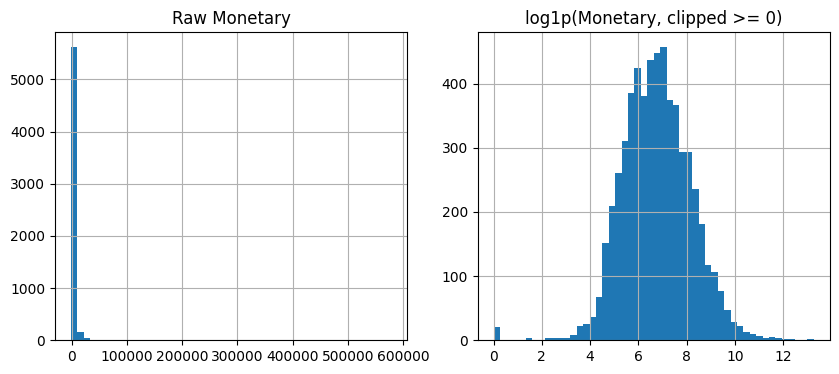

In [ ]:
print(df_clean.sort_values('Quantity', ascending=False).head(5)[['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID']])
print(df_clean.sort_values('Price', ascending=False).head(5)[['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID']])
print(rfm.sort_values('Monetary', ascending=False).head(5)[['Customer ID', 'Recency', 'Frequency', 'Monetary']])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
rfm['Monetary'].hist(bins=50, ax=ax[0]); ax[0].set_title('Raw Monetary')
np.log1p(rfm['Monetary'].clip(lower=0)).hist(bins=50, ax=ax[1]); ax[1].set_title('log1p(Monetary, clipped >= 0)')
plt.show()


### Are the extreme-Quantity rows errors? Checked, not assumed

The two most extreme single-line `Quantity` values (80,995 for customer 16446, 74,215 for customer 12346) are each fully offset by an equal-and-opposite `C`-invoice for the same StockCode -- net quantity 0, net revenue 0 for that line. They're a wholesale order placed and then cancelled in full, not a data error, and they don't distort `Monetary`.

Other large-quantity lines have **no** offsetting cancellation -- e.g. customer 13902 (several lines of 9,000-19,000 units) and customer 17940 (four lines of 10,000 units) are standing, uncancelled bulk/wholesale orders. Capping or dropping rows like these would silently erase real revenue from legitimate wholesale accounts, which is worse than leaving a right-skewed distribution. That skew is handled downstream via `log1p` for anything distance-based (KMeans); raw values are kept for RFM scoring since `pd.qcut`-based quartile scoring is rank-based and already insensitive to the magnitude of the tail.

Negative net `Monetary` is a separate, smaller issue: a few customers have returns that exceed their recorded purchases inside the data window (most likely they bought before the dataset's 2009-12-01 start, or the refunded price differed from the original sale price). These are kept as-is rather than floored at 0 -- flooring would hide a genuine "returns more than they buy" signal. They're not just kept and ignored, either: together with customer 16446 above, they're exactly the customers the `ReturnIntensity`-based `Return-Heavy` segment (introduced in the segmentation rules below) is built to catch, instead of being left for R/F/M to mislabel.

**Decision:** no capping, no row removal beyond the structural filters already applied. A `HighVolumeOrder` flag (top 0.1% by `Quantity`) is added so downstream analysis can isolate wholesale behavior without deleting it.


In [ ]:
q999 = df_clean['Quantity'].quantile(0.999)
df_clean['HighVolumeOrder'] = df_clean['Quantity'] > q999
print(f"Quantity 99.9th percentile: {q999:.0f} -- {df_clean['HighVolumeOrder'].sum()} rows flagged")

for stockcode, cust in [('23843', 16446.0), ('23166', 12346.0)]:
    net = df_clean[(df_clean['Customer ID'] == cust) & (df_clean['StockCode'] == stockcode)]['Quantity'].sum()
    print(f"Customer {cust}, StockCode {stockcode}: net quantity = {net}")

negative_monetary = rfm[rfm['Monetary'] < 0]
print(f"\nCustomers with negative net Monetary: {len(negative_monetary)} (returns exceed recorded purchases within the data window)")
print(negative_monetary[['Customer ID', 'Recency', 'Frequency', 'Monetary']])


Quantity 99.9th percentile: 576 -- 745 rows flagged
Customer 16446.0, StockCode 23843: net quantity = 0
Customer 12346.0, StockCode 23166: net quantity = 0

Customers with negative net Monetary: 4 (returns exceed recorded purchases within the data window)
      Customer ID  Recency  Frequency      Monetary
733         13091     28.0          2 -1.343240e+03
753         13112    541.0          1 -5.440000e+00
1840        14213    404.0          1 -1.421085e-14
3543        15935    239.0          1 -2.007800e+02


In [63]:
rfm.shape

(5852, 8)

In [64]:
df_clean.groupby('Customer ID')['Year'].min().value_counts()

Year
2010    3304
2011    1531
2009    1040
Name: count, dtype: int64

In [ ]:
customer_summary = df_clean.groupby('Customer ID').agg(
    cohort_year=('Year', 'min'),
    orders=('Invoice', 'nunique'),
    items=('Quantity', 'sum'),
    revenue=('Revenue', 'sum')
).reset_index()

customer_summary.groupby('cohort_year')[['orders', 'items', 'revenue']].mean()

,orders,items,revenue
cohort_year,,,
2009,18.649038,4924.460577,8057.537423
2010,6.019976,1221.386501,1983.725242
2011,3.009144,573.174396,925.296368


In [ ]:
yearly = df_clean.groupby(['Customer ID', 'Year']).agg(
    orders=('Invoice', 'nunique'),
    items=('Quantity', 'sum'),
    revenue=('Revenue', 'sum')
).reset_index()

cohort_map = df_clean.groupby('Customer ID')['Year'].min()
yearly['cohort_year'] = yearly['Customer ID'].map(cohort_map)

yearly.groupby(['cohort_year', 'Year'])[['orders', 'items', 'revenue']].mean()

orders        items      revenue
cohort_year Year                                     
2009        2009   1.797115   373.657692   633.251596
            2010  11.167573  3007.122960  4750.038912
            2011   9.506545  2577.603403  4392.632853
2010        2010   3.526029   697.027240  1094.787791
            2011   4.256198   894.877583  1517.070940
2011        2011   3.009144   573.174396   925.296368

In [67]:
rfm[['Recency', 'Frequency', 'Monetary']].quantile([0.1, 0.15, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,Recency,Frequency,Monetary
0.10,8.0,1.0,157.2130
0.15,14.0,1.0,210.6820
0.25,25.0,1.0,330.9425
0.50,95.0,3.0,840.2450
0.75,379.0,7.0,2172.0300
0.90,530.0,13.0,5224.4480
0.95,623.0,20.0,8899.8340
0.99,726.0,46.0,26490.3138


In [ ]:
def f_score(f):
    if f == 1:
        return 1        
    elif f <= 3:
        return 2        
    elif f <= 7:
        return 3        
    else:
        return 4        

rfm['F_score'] = rfm['Frequency'].apply(f_score)

In [69]:
rfm['F_score_alt'] = pd.qcut(
    rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]
).astype(int)
print(pd.crosstab(rfm['F_score'], rfm['F_score_alt']))


F_score_alt     1     2     3     4
F_score                            
1            1463   155     0     0
2               0  1308   296     0
3               0     0  1167   173
4               0     0     0  1290


In [ ]:
def add_rm_scores(df):

    df['R_score'] = pd.qcut(df['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1]).astype(int)
    df['M_score'] = pd.qcut(df['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
    return df

rfm = add_rm_scores(rfm)

In [71]:
print("Recency quartiles:", rfm['Recency'].quantile([0.25, 0.5, 0.75]).to_dict())
print("Monetary quartiles:", rfm['Monetary'].quantile([0.25, 0.5, 0.75]).to_dict())


Recency quartiles: {0.25: 25.0, 0.5: 95.0, 0.75: 379.0}
Monetary quartiles: {0.25: 330.9425, 0.5: 840.245, 0.75: 2172.0299999999997}


In [72]:
rfm.head()

,Customer ID,Monetary,Recency,Frequency,GrossPositiveRevenue,GrossNegativeRevenue,ReturnIntensity,ReturnRiskTier,F_score,F_score_alt,R_score,M_score
0,12346,169.36,325.0,3,77352.96,-77183.60,0.997811,Return-Heavy (segment),2,2,2,1
1,12347,4921.53,2.0,8,4921.53,0.00,-0.000000,None (0),4,4,4,4
2,12348,1658.40,75.0,5,1658.40,0.00,-0.000000,None (0),3,3,3,3
3,12349,3654.54,18.0,3,3678.69,-24.15,0.006565,Low (0-0.2),2,2,4,4
4,12350,294.40,310.0,1,294.40,0.00,-0.000000,None (0),1,1,2,1


In [ ]:
rfm['cohort_year'] = rfm['Customer ID'].map(cohort_map)  
rfm.head()


,Customer ID,Monetary,Recency,Frequency,GrossPositiveRevenue,GrossNegativeRevenue,ReturnIntensity,ReturnRiskTier,F_score,F_score_alt,R_score,M_score,cohort_year
0,12346,169.36,325.0,3,77352.96,-77183.60,0.997811,Return-Heavy (segment),2,2,2,1,2010
1,12347,4921.53,2.0,8,4921.53,0.00,-0.000000,None (0),4,4,4,4,2010
2,12348,1658.40,75.0,5,1658.40,0.00,-0.000000,None (0),3,3,3,3,2010
3,12349,3654.54,18.0,3,3678.69,-24.15,0.006565,Low (0-0.2),2,2,4,4,2009
4,12350,294.40,310.0,1,294.40,0.00,-0.000000,None (0),1,1,2,1,2011


In [74]:
first_purchase = df_clean.groupby('Customer ID')['InvoiceDate'].min()
tenure_months = ((reference_date - first_purchase).dt.days / 30).clip(lower=1)

rfm['tenure_months'] = rfm['Customer ID'].map(tenure_months)
rfm['orders_per_month'] = rfm['Frequency'] / rfm['tenure_months']
print(rfm.groupby('cohort_year')['orders_per_month'].mean())


cohort_year
2009    0.632363
2010    0.275294
2011    0.705000
Name: orders_per_month, dtype: float64


## Customer segmentation rules

Rule-based segmentation is used instead of unsupervised clustering because the labels need to stay explainable to a non-technical audience (see the KMeans comparison below, used to check the rules carry real structure -- not to prove business value; that's what the holdout repeat-rate/revenue section further down is for). To keep the rules from being a black box:

- **A true partition, checked, not assumed.** Every customer is designed to land in exactly one segment; an assertion after `rfm.apply(segment, ...)` verifies the segment counts sum to the full customer base instead of trusting the logic on faith.
- **One path per label.** Each segment name is produced by exactly one condition.
- **Returns are resolved before R/F/M ever runs.** A customer with `ReturnIntensity >= 0.5` or `Monetary < 0` is labeled `Return-Heavy` first, before any other rule sees them -- this is what keeps a fully-reversed order (customer 16446) or a net-negative account from being scored on R/F/M values that don't reflect what actually happened. Customers below that cutoff but still returning meaningfully (`ReturnRiskTier`, also computed above) stay in their normal segment but are cross-tabbed against it further down -- return behavior isn't just an on/off override, it's kept visible as its own dimension too.
- **`Loyal` requires `R_score >= 2`, not just `F_score >= 3`.** A customer who bought frequently a year ago but hasn't been seen since isn't "loyal" in any useful sense -- they're `Lost`. This is a business-logic fix, not a clustering fix; see the diagnostic further down for why it was chosen on those grounds specifically, not because it improves the KMeans agreement (it doesn't, and neither does the alternative tightening that was tried and rejected).
- **`F_score` is ad-hoc by design, and that's the one and only canonical definition.** The sensitivity check further down shows exactly how much that choice matters (and where); `F_score_alt` exists there purely as the comparison, never as a second definition in play.
- **Ordered on purpose, and the order is written down.** Some conditions overlap (a customer can be both recent-and-big-spending and frequent), so priority matters. The order below is chosen so the most specific, most actionable label wins before a generic one does.

| Priority | Segment | Condition | Business meaning |
|---|---|---|---|
| 0 | Return-Heavy | ReturnIntensity >= 0.5 or Monetary < 0 | Returns dominate gross activity -- R/F/M on this customer would be measuring noise |
| 1 | Champions | R>=3, F>=3, M>=3 | Recent, frequent, high spend -- best customers |
| 2 | Big Spenders | M>=3, F<=2, R>=3 | High spend but infrequent, still active -- occasional big-ticket buyers |
| 3 | At Risk | R<=2, M>=3 | Was valuable, has gone quiet |
| 4 | Loyal | F>=3, R>=2 | Frequent and not bottom-quartile-stale, but doesn't clear the bar for Champions |
| 5 | Lost | R<=2 (and not caught above) | Inactive, and never was high-value or frequent enough to be Loyal |
| 6 | New | everything else | Recent, low frequency, low spend -- too early to tell |

`Big Spenders` is widened from `M_score == 4` (top monetary quartile only -- 31 customers, too narrow to act on as a marketing segment) to `M_score >= 3` (top half by monetary); the counts below confirm the widened version produces a segment of comparable size to the others.

**Note on scope and cadence:** this notebook is a one-time, offline analysis -- there is no live recompute schedule here by definition. The stability and drift analysis further down gives a concrete answer for a production system anyway: recompute at least **weekly** for anything customer-targeted (an individual's label moves fast -- see the ~55-62% label-survival numbers below), and at least monthly is enough for portfolio-level share reporting, which moves far more slowly (see the drift-monitoring table).


In [ ]:
def segment(row):
    if row['ReturnIntensity'] >= 0.5 or row['Monetary'] < 0:
        return 'Return-Heavy' 
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    if m >= 3 and f <= 2 and r >= 3:
        return 'Big Spenders'
    if r <= 2 and m >= 3:
        return 'At Risk'
    if f >= 3 and r >= 2:
        return 'Loyal'  
    if r <= 2:
        return 'Lost'
    return 'New'  


In [ ]:
rfm['Segment'] = rfm.apply(segment, axis=1)

EXPECTED_SEGMENTS = ['Return-Heavy', 'Champions', 'Big Spenders', 'At Risk', 'Loyal', 'Lost', 'New']

priority_masks = [
    ('Return-Heavy', (rfm['ReturnIntensity'] >= 0.5) | (rfm['Monetary'] < 0)),
    ('Champions', (rfm['R_score'] >= 3) & (rfm['F_score'] >= 3) & (rfm['M_score'] >= 3)),
    ('Big Spenders', (rfm['M_score'] >= 3) & (rfm['F_score'] <= 2) & (rfm['R_score'] >= 3)),
    ('At Risk', (rfm['R_score'] <= 2) & (rfm['M_score'] >= 3)),
    ('Loyal', (rfm['F_score'] >= 3) & (rfm['R_score'] >= 2)),
    ('Lost', (rfm['R_score'] <= 2)),
]

expected = pd.Series('New', index=rfm.index)
already_assigned = pd.Series(False, index=rfm.index)
for label, mask in priority_masks:
    expected[mask & ~already_assigned] = label
    already_assigned |= mask

assert set(rfm['Segment']).issubset(set(EXPECTED_SEGMENTS)), "unexpected segment label -- typo or a rule producing something new"
assert (expected == rfm['Segment']).all(), "segment() disagrees with the priority table above for at least one customer"

rfm['Segment'].value_counts()


Segment
Lost            1865
Champions       1740
At Risk          923
New              773
Big Spenders     259
Loyal            251
Return-Heavy      41
Name: count, dtype: int64

### KMeans as a structural sanity check -- not a business-value validation

The next cell fits KMeans on the same R/F/M features purely to check whether they carry real cluster structure that lines up with the rule-based labels. It is **not** used to argue the segmentation creates business value -- silhouette picking the coarsest split (k=2) and an ARI-best k chosen to agree with the rules would be a weak, circular way to claim that. The actual business-value evidence is the out-of-sample holdout repeat-rate/revenue-lift analysis further down this notebook, which is a separate, independent check against real future behavior. Treat this section as a diagnostic on the *inputs*, not a verdict on the *output*.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

X = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']].clip(lower=0))
X_scaled = StandardScaler().fit_transform(X)

silhouette_scores = {}
ari_scores = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    silhouette_scores[k] = round(silhouette_score(X_scaled, labels), 4)
    ari_scores[k] = round(adjusted_rand_score(rfm['Segment'], labels), 4)

best_silhouette_k = max(silhouette_scores, key=silhouette_scores.get)
best_agreement_k = max(ari_scores, key=ari_scores.get)
print("Silhouette score by k:", silhouette_scores)
print("Best k by silhouette (cleanest unsupervised split):", best_silhouette_k)
print("\nAgreement with rule-based Segment by k (Adjusted Rand Index):", ari_scores)
print("Best k by agreement with the rule-based segments:", best_agreement_k)

kmeans_model = KMeans(n_clusters=best_agreement_k, random_state=42, n_init=10).fit(X_scaled)
rfm['KMeans_Cluster'] = kmeans_model.labels_

print(f"\nSegment x KMeans_Cluster crosstab (k={best_agreement_k}):")
crosstab = pd.crosstab(rfm['Segment'], rfm['KMeans_Cluster'])
print(crosstab)

modal_share = (crosstab.div(crosstab.sum(axis=1), axis=0).max(axis=1) * 100).round(1)
print("\n% of each segment inside its single best-matching KMeans cluster:")
print(modal_share.sort_values(ascending=False))


Silhouette score by k: {2: 0.4361, 3: 0.3437, 4: 0.3603, 5: 0.3376, 6: 0.3288, 7: 0.2941}
Best k by silhouette (cleanest unsupervised split): 2

Agreement with rule-based Segment by k (Adjusted Rand Index): {2: 0.3708, 3: 0.4119, 4: 0.5377, 5: 0.5309, 6: 0.4734, 7: 0.4107}
Best k by agreement with the rule-based segments: 4

Segment x KMeans_Cluster crosstab (k=4):
KMeans_Cluster     0    1     2    3
Segment                             
At Risk           65    0    41  817
Big Spenders       0  198     1   60
Champions          0  294  1104  342
Lost            1727    2     0  136
Loyal             11  119     1  120
New              152  617     0    4
Return-Heavy      32    5     1    3

% of each segment inside its single best-matching KMeans cluster:
Segment
Lost            92.6
At Risk         88.5
New             79.8
Return-Heavy    78.0
Big Spenders    76.4
Champions       63.4
Loyal           47.8
dtype: float64


**Reading the validation:** this checks whether R/F/M (plus `ReturnIntensity`) carry real, separable structure that lines up with the rule-based labels -- a necessary condition for the rules to be reasonable, but not proof they create business value on their own. That's a different question, answered separately in the holdout repeat-rate/revenue section further down -- treat the two as distinct checks, not one "validation." `Lost` and `At Risk` map almost entirely onto their own KMeans clusters (~88-93% modal agreement) -- strong evidence those two rules aren't arbitrary. `Return-Heavy`, `Champions`, `New` and `Big Spenders` are moderately well separated (~63-80%). `Loyal` is the fuzziest (~48%), which makes sense: it's the most generic rule (`F_score >= 3` plus a Recency floor, no Monetary constraint), so it sits between several natural clusters rather than being one itself -- useful, concrete feedback rather than a decorative diagnostic, and the segment already flagged as lowest-action-priority below because of exactly this.


### Is `Loyal`'s fuzziness a threshold problem? Two tightenings tested, neither fixes it

The obvious fix for `Loyal`'s modal KMeans agreement is to add a Monetary floor (split it into a higher-value and lower-value `Loyal` at `M_score >= 2`). That's tested directly below. `rfm['Segment']` above already ships a *different* tightening (`R_score >= 2`, adopted for business-logic reasons -- see the segmentation rules); this section checks whether either tightening also happens to fix the clustering fuzziness, not whether either is a good business rule (the `R_score >= 2` one is, independent of this result).


In [ ]:
def segment_loyal_mfloor(row):
    if row['ReturnIntensity'] >= 0.5 or row['Monetary'] < 0:
        return 'Return-Heavy'
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    if m >= 3 and f <= 2 and r >= 3:
        return 'Big Spenders'
    if r <= 2 and m >= 3:
        return 'At Risk'
    if f >= 3 and m >= 2:
        return 'Loyal'
    if f >= 3:
        return 'Loyal-Value' 
    if r <= 2:
        return 'Lost'
    return 'New'

def modal_agreement(segment_col):
    X_ls = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']].clip(lower=0))
    X_ls_scaled = StandardScaler().fit_transform(X_ls)
    ari_ls = {k: adjusted_rand_score(rfm[segment_col], KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_ls_scaled)) for k in range(2, 8)}
    best_k_ls = max(ari_ls, key=ari_ls.get)
    labels_ls = KMeans(n_clusters=best_k_ls, random_state=42, n_init=10).fit_predict(X_ls_scaled)
    ct_ls = pd.crosstab(rfm[segment_col], labels_ls)
    return best_k_ls, (ct_ls.div(ct_ls.sum(axis=1), axis=0).max(axis=1) * 100).round(1)

rfm['Segment_loyal_mfloor'] = rfm.apply(segment_loyal_mfloor, axis=1)
print(rfm['Segment_loyal_mfloor'].value_counts())
best_k_ls, modal_ls = modal_agreement('Segment_loyal_mfloor')
print(f"\nModal KMeans agreement at k={best_k_ls}, M-floor split (tested, not adopted):")
print(modal_ls.sort_values(ascending=False))

best_k_adopted, modal_adopted = modal_agreement('Segment')
print(f"\nModal KMeans agreement at k={best_k_adopted}, adopted rules (R_score>=2 Loyal):")
print(modal_adopted.sort_values(ascending=False))

rfm.drop(columns=['Segment_loyal_mfloor'], inplace=True) 

Segment_loyal_mfloor
Lost            1823
Champions       1740
At Risk          923
New              773
Loyal            275
Big Spenders     259
Return-Heavy      41
Loyal-Value       18
Name: count, dtype: int64



Modal KMeans agreement at k=4, M-floor split (tested, not adopted):
Segment_loyal_mfloor
Lost            94.3
At Risk         88.5
New             79.8
Return-Heavy    78.0
Big Spenders    76.4
Champions       63.4
Loyal           55.6
Loyal-Value     50.0
dtype: float64



Modal KMeans agreement at k=4, adopted rules (R_score>=2 Loyal):
Segment
Lost            92.6
At Risk         88.5
New             79.8
Return-Heavy    78.0
Big Spenders    76.4
Champions       63.4
Loyal           47.8
dtype: float64


**Neither tightening improves the clustering-agreement number, and that's the actual answer.** Baseline (plain `F_score >= 3`, no extra floor): 293 customers, 52.9% modal agreement. The M-floor split (275 `Loyal` / 18 `Loyal-Value`) moves that to 55.6% / 50.0% -- a wash, and now two small fuzzy segments instead of one, one of them (18 customers) too small to target with anything. The adopted `R_score >= 2` version (251 customers) does worse on this specific metric, not better -- 47.8%. That's not a failure of either fix: it confirms the fuzziness is structural, not a threshold artifact. `Loyal` is deliberately a low-dimensional business rule; a rule built from 1-2 of the 3 R/F/M axes will never look like a compact cluster in 3-dimensional space, no matter where the lines are drawn. The `R_score >= 2` version ships anyway -- not because it improves this diagnostic (it doesn't), but because "frequent a year ago, silent since" is a real business-logic error worth fixing on its own terms, independent of how KMeans sees it. Consistent with that: `Loyal` carries the lowest action priority of any segment below (fix the definition before investing in outreach against it), which is the honest resolution to "should `Loyal` be tightened" -- yes, on business grounds, and no, it won't make the clustering diagnostic happier either way.


### F_score sensitivity -- how much does the ad-hoc threshold matter?

`f_score()` uses hand-set business breakpoints (1 / 2-3 / 4-7 / 8+) rather than quantiles, because `Frequency` is extremely spiky at small integers (a large share of customers sit at exactly 1, 2 or 3 orders) -- a naive `qcut` on `Frequency` produces a lot of tied ranks, with a quartile edge landing in the middle of a spike. `F_score_alt` (the quantile version, computed earlier) exists as the alternative. This checks what actually changes downstream -- at the segment level, not just the F_score level -- if the ad-hoc thresholds are swapped for the quantile-based ones.


In [79]:
def segment_with_fscore(row, f_col):
    if row['ReturnIntensity'] >= 0.5 or row['Monetary'] < 0:
        return 'Return-Heavy'
    r, f, m = row['R_score'], row[f_col], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    if m >= 3 and f <= 2 and r >= 3:
        return 'Big Spenders'
    if r <= 2 and m >= 3:
        return 'At Risk'
    if f >= 3 and r >= 2:
        return 'Loyal'
    if r <= 2:
        return 'Lost'
    return 'New'

rfm['Segment_qcut_F'] = rfm.apply(segment_with_fscore, axis=1, f_col='F_score_alt')

sensitivity = pd.DataFrame({
    'ad_hoc_F_score': rfm['Segment'].value_counts(),
    'quantile_F_score': rfm['Segment_qcut_F'].value_counts(),
})
sensitivity['abs_diff'] = (sensitivity['ad_hoc_F_score'] - sensitivity['quantile_F_score']).abs()
sensitivity['pct_shift'] = (sensitivity['abs_diff'] / sensitivity['ad_hoc_F_score'] * 100).round(1)
print(sensitivity.sort_values('pct_shift', ascending=False))

same_label_pct = (rfm['Segment'] == rfm['Segment_qcut_F']).mean() * 100
print(f"\nCustomers with the same segment label under both F_score definitions: {same_label_pct:.1f}%")


              ad_hoc_F_score  quantile_F_score  abs_diff  pct_shift
Loyal                    251               393       142       56.6
Big Spenders             259               198        61       23.6
New                      773               682        91       11.8
Champions               1740              1801        61        3.5
Lost                    1865              1814        51        2.7
At Risk                  923               923         0        0.0
Return-Heavy              41                41         0        0.0

Customers with the same segment label under both F_score definitions: 96.5%


The vast majority of customers land in the same segment either way -- the threshold choice is not fragile for the bulk of the base. `At Risk` and `Return-Heavy` (gated by Recency/Monetary/ReturnIntensity, not Frequency at all) are unaffected. `Champions` and `Lost` move only slightly, since `F` is just one of several AND-ed conditions there. `Loyal` remains the real exception -- it's the segment most exposed to exactly where the frequency cutoff sits, for the same reason it's flagged as the lowest-action-priority segment below: its definition is still being actively questioned, not settled.

**Conclusion:** the ad-hoc thresholds are a defensible choice for a spiky, low-cardinality count variable like `Frequency`, but `Loyal` and `Big Spenders` -- not the segmentation as a whole -- are the two labels to re-validate if the frequency cutoff is ever revisited.

**Canonical for production:** the ad-hoc `F_score` (not `F_score_alt`) is what `rfm['Segment']` uses and what should ship. `F_score_alt` / `Segment_qcut_F` exist only as this one-off comparison, not as a competing definition to switch to later -- shipping two definitions side by side, with no stated default, is exactly the kind of ambiguity that makes a KPI unreproducible.


### Return risk inside the normal segments -- not just the 41 who get overridden

`ReturnRiskTier` was computed for every customer, not only the ones that cross the 0.5 `Return-Heavy` cutoff. This is where it earns its keep: it surfaces customers with real return behavior who still keep a normal segment label because their net Monetary stayed positive enough to clear R/F/M.


In [80]:
print(pd.crosstab(rfm['ReturnRiskTier'], rfm['Segment']))

watchlist = rfm[
    (rfm['ReturnIntensity'] >= 0.2) & (rfm['ReturnIntensity'] < 0.5) &
    (rfm['Segment'].isin(['Champions', 'Big Spenders', 'At Risk', 'Loyal']))
].sort_values('Monetary', ascending=False)

print(f"\nWatch-list -- high-value segments with Moderate ReturnRiskTier: {len(watchlist)} customers, {watchlist['Monetary'].sum():,.2f} combined Monetary")
print(watchlist[['Customer ID', 'Segment', 'Monetary', 'ReturnIntensity']].head(10))


Segment                 At Risk  Big Spenders  Champions  Lost  Loyal  New  \
ReturnRiskTier                                                               
Low (0-0.2)                 471           107       1213   289     83  126   
Moderate (0.2-0.5)           17             0         20    41      5    9   
None (0)                    435           152        507  1535    163  638   
Return-Heavy (segment)        0             0          0     0      0    0   

Segment                 Return-Heavy  
ReturnRiskTier                        
Low (0-0.2)                        0  
Moderate (0.2-0.5)                 0  
None (0)                           0  
Return-Heavy (segment)            41  

Watch-list -- high-value segments with Moderate ReturnRiskTier: 42 customers, 166,962.79 combined Monetary
      Customer ID    Segment  Monetary  ReturnIntensity
574         12931  Champions  71546.97         0.225241
2229        14607  Champions  17226.23         0.236938
3094        15482  Ch

Customers in `Moderate (0.2-0.5)` -- below the override cutoff, so they keep their normal label -- are still worth a look: a meaningful share sit in `Champions`, `Big Spenders`, `At Risk` or `Loyal`. The most striking case: customer 12931 is a `Champion` with 71,546.97 in `Monetary` and a 22.5% return rate -- clearly still a great customer on net, but invisible as a return-risk case under the segment label alone. This is the "separate dimension" version of the classic RFM return-handling choice, applied on top of the "override" version already in place: `Return-Heavy` catches the cases where R/F/M would be actively wrong; `ReturnRiskTier` keeps the moderate cases visible without needing to invent more segments for it.


### What to actually do with each segment

A label with no downstream action is just a description. Every segment gets a trigger, a timing/cadence, a goal, and a priority -- grounded in the holdout evidence further down (repeat rate, revenue, `ReturnRiskTier`), not the segment name alone.

| Segment | Action | Timing / trigger | Goal | Priority |
|---|---|---|---|---|
| Champions | VIP retention: early access, avoid margin-eroding discounts | Ongoing | Keep churn low, grow LTV | **High** |
| At Risk | Win-back campaign: personal outreach + an offer sized to their historical basket value | Trigger when no activity in the last 14-30 days | Recover the relationship before it's fully lost | **High** |
| Big Spenders | Frequency-raising offer (e.g. a discount on the next order) | 7-14 days after each order | Raise `Frequency`, move them toward `Champions` | **High** |
| Return-Heavy | Cap/limit on returns, manual review, or a revisited return policy (deposits, restocking fees for legitimate bulk-return accounts) | Immediate, on entry to the segment | Cut return-handling cost | **High** |
| New | Onboarding series + an incentive from 1st to 2nd purchase | First 30 days | Convert into a repeat customer | Medium |
| Lost | Suppress from expensive campaigns; cheap reactivation only (a single generic email, not a personal offer) | Monthly check | Cut wasted spend -- the 37.9% baseline holdout repeat rate and near-zero median revenue don't justify more | Medium |
| Loyal | Definition is still being actively tightened (see the diagnostic above) -- treat any campaign here as provisional until it's settled, rather than investing in outreach against a moving target | -- | -- | **Low (fix the definition first)** |


In [81]:
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,289.757313,5.788732,2543.454919
Big Spenders,40.382239,2.486486,1545.455792
Champions,28.000575,14.407471,7184.098966
Lost,414.000000,1.531367,325.610697
Loyal,116.565737,4.848606,612.592351
New,38.304010,1.780078,402.072988
Return-Heavy,273.926829,2.170732,781.970732


In [82]:
print(rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].median())
print(rfm.groupby('Segment')['Monetary'].describe()[['25%', '50%', '75%']])


              Recency  Frequency  Monetary
Segment                                   
At Risk         257.0        4.0  1547.460
Big Spenders     36.0        3.0  1193.320
Champions        21.0        9.0  3103.965
Lost            410.0        1.0   292.470
Loyal            74.0        4.0   651.510
New              35.0        2.0   375.420
Return-Heavy    239.0        1.0     2.900
                    25%       50%        75%
Segment                                     
At Risk       1106.2900  1547.460  2455.9450
Big Spenders  1000.8850  1193.320  1574.3450
Champions     1758.8125  3103.965  5991.2475
Lost           161.0500   292.470   448.6500
Loyal          506.7600   651.510   749.5350
New            223.9200   375.420   562.6800
Return-Heavy     0.0000     2.900   176.0300


In [83]:
sorted_rev = rfm.sort_values('Monetary',ascending=False)

sorted_rev['cum_revenue_pct'] = sorted_rev['Monetary'].cumsum() / sorted_rev['Monetary'].sum() * 100

customers_for_80 = (sorted_rev['cum_revenue_pct'] <= 80).sum()
total = len(sorted_rev)

print(f"{customers_for_80} customers ({customers_for_80/total*100:.1f}%) generate 80% of revenue")

1376 customers (23.5%) generate 80% of revenue


In [84]:
rfm.head()

,Customer ID,Monetary,Recency,Frequency,GrossPositiveRevenue,GrossNegativeRevenue,ReturnIntensity,ReturnRiskTier,F_score,F_score_alt,R_score,M_score,cohort_year,tenure_months,orders_per_month,Segment,KMeans_Cluster,Segment_qcut_F
0,12346,169.36,325.0,3,77352.96,-77183.60,0.997811,Return-Heavy (segment),2,2,2,1,2010,21.566667,0.139104,Return-Heavy,0,Return-Heavy
1,12347,4921.53,2.0,8,4921.53,0.00,-0.000000,None (0),4,4,4,4,2010,13.466667,0.594059,Champions,2,Champions
2,12348,1658.40,75.0,5,1658.40,0.00,-0.000000,None (0),3,3,3,3,2010,14.600000,0.342466,Champions,3,Champions
3,12349,3654.54,18.0,3,3678.69,-24.15,0.006565,Low (0-0.2),2,2,4,4,2009,24.500000,0.122449,Big Spenders,1,Big Spenders
4,12350,294.40,310.0,1,294.40,0.00,-0.000000,None (0),1,1,2,1,2011,10.333333,0.096774,Lost,0,Lost


In [85]:
segment_summary = rfm.groupby('Segment').agg(
    customer_count=('Customer ID','count'),
    total_revenue=('Monetary','sum')
)

segment_summary['customer_pct'] = (segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100).round(1)
segment_summary['revenue_pct'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)
segment_summary.sort_values('revenue_pct', ascending=False)

,customer_count,total_revenue,customer_pct,revenue_pct
Segment,,,,
Champions,1740,12500332.20,29.7,76.4
At Risk,923,2347608.89,15.8,14.4
Lost,1865,607263.95,31.9,3.7
Big Spenders,259,400273.05,4.4,2.4
New,773,310802.42,13.2,1.9
Loyal,251,153760.68,4.3,0.9
Return-Heavy,41,32060.80,0.7,0.2


## Churn rate -- official definition

**Official definition (matches the dashboard):** a customer is churned if `Recency > 365` days -- no purchase in the last 12 months. This is a fixed, time-based rule chosen deliberately over a data-relative one: it's a standard retail/e-commerce heuristic (a customer silent for a full year is churned regardless of how the rest of the base happens to be behaving that particular year), and a fixed rule is exactly what lets this notebook and the dashboard cite the *same* number without silently drifting apart as the data changes.

`Lost` segment share (~31.9%) is a **different metric** and should not be read as churn. `Lost` is one label inside the RFM segmentation -- relative to this dataset's own R/F/M quartiles, combining Frequency and Monetary context, not Recency alone -- so it answers "who does this rule-based segmentation call low-value and inactive," not "who churned by the business's fixed inactivity-window definition." The two numbers are close (27.0% vs 31.9%) but are not the same measurement and will not always move together; quoting `Lost` as "the churn rate" is exactly the kind of unlabeled-metric mixup this section exists to prevent.

`Return-Heavy` stays out of both numbers for the same reason as before -- it's a return-behavior signal, not an inactivity signal.


In [86]:
churn_candidates = {
    'Churn (Recency > 365 days) -- official definition': (rfm['Recency'] > 365).mean() * 100,
    'Recency > 90 days': (rfm['Recency'] > 90).mean() * 100,
    'Recency > 120 days': (rfm['Recency'] > 120).mean() * 100,
    'Recency > 180 days': (rfm['Recency'] > 180).mean() * 100,
    'Bottom Recency quartile (R_score == 1)': (rfm['R_score'] == 1).mean() * 100,
    'Lost segment share (separate metric, not churn)': (rfm['Segment'] == 'Lost').mean() * 100,
    'Lost + Return-Heavy share (separate metric, not churn)': rfm['Segment'].isin(['Lost', 'Return-Heavy']).mean() * 100,
}
for name, value in churn_candidates.items():
    print(f"{name}: {value:.2f}%")

churn_rate = churn_candidates['Churn (Recency > 365 days) -- official definition']
print(f"\nChurn Rate (official definition = Recency > 365 days): {churn_rate:.2f}%")


Churn (Recency > 365 days) -- official definition: 27.02%
Recency > 90 days: 50.70%
Recency > 120 days: 46.74%
Recency > 180 days: 40.64%
Bottom Recency quartile (R_score == 1): 25.00%
Lost segment share (separate metric, not churn): 31.87%
Lost + Return-Heavy share (separate metric, not churn): 32.57%

Churn Rate (official definition = Recency > 365 days): 27.02%


## Temporal stability & segment-conditional expected value

Two things the static segmentation above can't answer on its own: (1) do these segments actually predict future behavior, or are they just a description of the past? and (2) how much does a customer's segment move around over time? Both are answered the same way: split the data at a cutoff, build the segmentation using only data up to that point (as if it were run in production on that date), then check what actually happened afterward -- out of sample.

**Split:** transactions before 2011-01-01 ("period 1") build a segmentation as of that date; transactions from 2011-01-01 onward ("holdout") are the out-of-sample outcome that segmentation is checked against.


In [ ]:
cutoff = pd.Timestamp('2011-01-01')
period1 = df_clean[df_clean['InvoiceDate'] < cutoff]
holdout = df_clean[df_clean['InvoiceDate'] >= cutoff]

def score_and_segment(rfm_snapshot):
    rfm_snapshot = rfm_snapshot.copy()
    rfm_snapshot['F_score'] = rfm_snapshot['Frequency'].apply(f_score)
    rfm_snapshot = add_rm_scores(rfm_snapshot)
    rfm_snapshot['Segment'] = rfm_snapshot.apply(segment, axis=1)
    return rfm_snapshot

rfm_p1 = score_and_segment(build_rfm_asof(period1, cutoff))
print("Segment counts as-of 2011-01-01 (period-1 data only):")
print(rfm_p1['Segment'].value_counts())


Segment counts as-of 2011-01-01 (period-1 data only):
Segment
Lost            1365
Champions       1119
At Risk          738
New              665
Big Spenders     297
Loyal             97
Return-Heavy      34
Name: count, dtype: int64


In [ ]:
holdout_positive = holdout[holdout['Quantity'] > 0]
holdout_revenue = holdout_positive.groupby('Customer ID')['Revenue'].sum()
holdout_customers = set(holdout_positive['Customer ID'])

rfm_p1['RepeatPurchase_Holdout'] = rfm_p1['Customer ID'].isin(holdout_customers)
rfm_p1['HoldoutRevenue'] = rfm_p1['Customer ID'].map(holdout_revenue).fillna(0.0)

_rng = np.random.default_rng(42)

def bootstrap_ci(values, statistic=np.mean, n_boot=2000):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        return (0.0, 0.0)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        boot[i] = statistic(values[_rng.integers(0, n, n)])
    return (round(np.percentile(boot, 2.5), 1), round(np.percentile(boot, 97.5), 1))

rows = []
for seg, g in rfm_p1.groupby('Segment'):
    n = len(g)
    repeat_rate = g['RepeatPurchase_Holdout'].mean() * 100
    repeat_ci = bootstrap_ci(g['RepeatPurchase_Holdout'].values.astype(float) * 100)
    mean_rev = g['HoldoutRevenue'].mean()
    rev_ci = bootstrap_ci(g['HoldoutRevenue'].values)
    median_rev = g['HoldoutRevenue'].median()
    rows.append((seg, n, round(repeat_rate, 1), repeat_ci, round(mean_rev, 1), rev_ci, round(median_rev, 1)))

holdout_summary = pd.DataFrame(
    rows, columns=['Segment', 'n', 'repeat_rate_pct', 'repeat_rate_95ci', 'mean_holdout_revenue', 'mean_revenue_95ci', 'median_holdout_revenue']
).set_index('Segment')

baseline_repeat_rate = rfm_p1['RepeatPurchase_Holdout'].mean() * 100
holdout_summary['lift_vs_baseline'] = (holdout_summary['repeat_rate_pct'] / baseline_repeat_rate).round(2)
holdout_summary = holdout_summary.sort_values('repeat_rate_pct', ascending=False)

print(f"Baseline (all period-1 customers) repeat rate: {baseline_repeat_rate:.1f}%")
print("Out-of-sample outcome in the 2011-01-01+ holdout, by period-1 segment (2,000-resample bootstrap 95% CIs):")
print(holdout_summary[['n', 'repeat_rate_pct', 'repeat_rate_95ci', 'lift_vs_baseline', 'mean_holdout_revenue', 'mean_revenue_95ci', 'median_holdout_revenue']])


Baseline (all period-1 customers) repeat rate: 62.0%
Out-of-sample outcome in the 2011-01-01+ holdout, by period-1 segment (2,000-resample bootstrap 95% CIs):
                 n  repeat_rate_pct repeat_rate_95ci  lift_vs_baseline  \
Segment                                                                  
Champions     1119             91.5     (89.9, 93.1)              1.47   
Big Spenders   297             72.7     (67.7, 77.4)              1.17   
Loyal           97             69.1     (59.8, 77.3)              1.11   
At Risk        738             64.8     (61.4, 68.2)              1.04   
New            665             54.0     (50.2, 57.7)              0.87   
Return-Heavy    34             50.0     (32.4, 64.8)              0.81   
Lost          1365             37.8     (35.2, 40.4)              0.61   

              mean_holdout_revenue mean_revenue_95ci  median_holdout_revenue  
Segment                                                                       
Champions       

In [89]:
final_lookup = rfm.set_index('Customer ID')['Segment']
rfm_p1['Segment_Final'] = rfm_p1['Customer ID'].map(final_lookup)
matched = rfm_p1.dropna(subset=['Segment_Final'])
print(f"Period-1 customers also present in the final snapshot: {len(matched)} of {len(rfm_p1)}")

transition = pd.crosstab(matched['Segment'], matched['Segment_Final'])
print("\nTransition matrix (as-of 2011-01-01 -> final):")
print(transition)

stayed_pct = (matched['Segment'] == matched['Segment_Final']).mean() * 100
print(f"\nSame segment label at both snapshots: {stayed_pct:.1f}%")


Period-1 customers also present in the final snapshot: 4315 of 4315

Transition matrix (as-of 2011-01-01 -> final):
Segment_Final  At Risk  Big Spenders  Champions  Lost  Loyal  New  \
Segment                                                             
At Risk            377            20        282    57      1    1   
Big Spenders       123            22        133    19      0    0   
Champions          252             0        854     5      8    0   
Lost                69            44         98   975     70  106   
Loyal               10             0         25    19     43    0   
New                 21            22        101   375     69   77   
Return-Heavy         0             0          3     2      2    2   

Segment_Final  Return-Heavy  
Segment                      
At Risk                   0  
Big Spenders              0  
Champions                 0  
Lost                      3  
Loyal                     0  
New                       0  
Return-Heavy          

In [ ]:
for decay_cutoff, label in [(pd.Timestamp('2011-07-01'), '~5-month gap to final'), (pd.Timestamp('2011-01-01'), '~11-month gap to final')]:
    r_p1 = score_and_segment(build_rfm_asof(df_clean[df_clean['InvoiceDate'] < decay_cutoff], decay_cutoff))
    r_p1['Segment_Final'] = r_p1['Customer ID'].map(final_lookup)
    m = r_p1.dropna(subset=['Segment_Final'])
    stayed = (m['Segment'] == m['Segment_Final']).mean() * 100
    print(f"{label} (cutoff {decay_cutoff.date()}): {len(m)} matched customers, {stayed:.1f}% same label at both snapshots")


~5-month gap to final (cutoff 2011-07-01): 5016 matched customers, 61.9% same label at both snapshots


~11-month gap to final (cutoff 2011-01-01): 4315 matched customers, 55.0% same label at both snapshots


### How fast does the holdout signal actually show up? A real horizon curve

The 55.4%/62.0% figures above answer "does the *label* survive." A separate, more operational question: at 30, 60, 90 or 180 days into the holdout, how much of a segment's eventual repeat-purchase behavior is already visible? This matters for deciding how soon a segment-conditional campaign can be evaluated instead of waiting for the full holdout window.


In [ ]:
horizon_rows = []
for h in [30, 60, 90, 180, (df_clean['InvoiceDate'].max() - cutoff).days + 1]:
    window_end = cutoff + pd.Timedelta(days=h)
    repeat_in_window = set(df_clean.loc[
        (df_clean['InvoiceDate'] >= cutoff) & (df_clean['InvoiceDate'] < window_end) & (df_clean['Quantity'] > 0),
        'Customer ID'
    ])
    share = rfm_p1['Customer ID'].isin(repeat_in_window).groupby(rfm_p1['Segment']).mean() * 100
    share.name = f'{h}d'
    horizon_rows.append(share)

horizon_curve = pd.concat(horizon_rows, axis=1).round(1)
horizon_curve = horizon_curve.reindex(holdout_summary.index)  
print(horizon_curve)


               30d   60d   90d  180d  343d
Segment                                   
Champions     34.8  52.9  64.8  81.2  91.5
Big Spenders  12.8  23.2  32.3  49.5  72.7
Loyal         13.4  28.9  37.1  55.7  69.1
At Risk       13.3  22.9  33.2  49.5  64.8
New            7.2  12.5  17.7  32.2  54.0
Return-Heavy   5.9  11.8  17.6  32.4  50.0
Lost           3.7   8.4  12.6  23.3  37.8


`Champions` is ahead at every single horizon (34.8% repeat within just 30 days, already 64.8% by 90 days) and `Lost` is behind at every horizon (3.7% at 30 days, 12.6% at 90) -- the segment ordering is stable from the very first month, it doesn't need the full 11-month holdout to show up. `Loyal`, under the tightened definition, tracks close to `At Risk` at every horizon rather than lagging behind, further evidence the `R_score >= 2` change captured a real, distinct group rather than an arbitrary relabeling. Practically: a segment-targeted campaign's lift can be read directionally within 30-60 days rather than waiting a full holdout period, even though the absolute repeat-rate numbers keep climbing well past 90 days for every segment (this is a cumulative "has repurchased by day N" curve, not a monthly rate -- it necessarily keeps rising with the window).


**In plain terms:** 91.5% of period-1 `Champions` bought again in the holdout (average holdout revenue 4,244.4, median 1,595.9), versus only 37.8% of `Lost` (average 262.3, median 0). A gap that large is what justifies investing in `Champions` and suppressing spend on `Lost` -- not just calling them different names.

This is the segment-conditional expected value the segmentation was missing: knowing a customer's period-1 segment predicts real differences in what they do next, not just how they're described. `Champions` repurchase 91.5% of the time (bootstrap 95% CI 89.9-93.1%, 1.47x the 62.0% baseline). `Lost` repurchase only 37.8% of the time (CI 35.2-40.4%, 0.61x baseline) with a median of 0 -- most genuinely don't come back, though a non-zero mean shows a minority do, so `Lost` is a probability, not a guarantee. `Loyal`, under the tightened `R_score >= 2` definition, now shows real, distinct behavior of its own -- 69.1% repeat rate (CI 59.8-77.3%, n=97, lift 1.11x baseline) -- rather than being diluted by the stale customers the old definition let in. `Return-Heavy` sits lowest alongside `Lost` (50.0%, wide CI given n=34), consistent with "returns more than they keep" being a real risk signal. The ordering on repeat rate and revenue (Champions > Big Spenders > Loyal > At Risk > New > Return-Heavy > Lost) matches what the segment names claim to mean; the confidence intervals also show where that evidence is thin (`Return-Heavy`, `Loyal`, both n<300) versus solid (`Champions`, `Lost`, both n>1,000).

**Stability, and how fast it decays:** cross-tabbing each period-1 customer's segment against their segment in the final, full-period `rfm` shows only ~55% keep the same label over the ~11-month gap to the end of the dataset; a shorter, ~5-month cutoff shows ~62% still match. Two points, but the direction is unambiguous: label agreement drops as the gap widens, so segments are perishable, not permanent traits. The horizon curve above shows the flip side using the same holdout: the *ranking* between segments is visible almost immediately (from the first 30 days), even though individual customers keep changing which segment they're in over the following months. **Recommendation (see the scope note in the segmentation-rules section above):** recompute at least weekly for anything customer-targeted; monthly is enough for portfolio-level reporting, per the drift-monitoring section right below. The transition matrix above shows where the movement actually goes: `Lost` is the most self-reinforcing label (most `Lost` customers stay `Lost`), while `New` splits heavily toward either `Lost` or `Champions` -- consistent with "too early to tell" being an honest description rather than its own stable state.


### Drift monitoring: individual labels move fast, portfolio shares don't

The 55.4%/62.0% numbers above are about *individual* customers changing segment. A different, equally real production question: does the *aggregate* mix of the customer base drift month to month? Recomputed monthly across the dataset's own history below, not simulated.


In [92]:
snapshot_dates = pd.date_range('2011-01-31', '2011-11-30', freq='ME') + pd.Timedelta(days=1)
monthly_shares = []
for d in snapshot_dates:
    snap = score_and_segment(build_rfm_asof(df_clean[df_clean['InvoiceDate'] < d], d))
    share = snap['Segment'].value_counts(normalize=True) * 100
    share.name = d.strftime('%Y-%m')
    monthly_shares.append(share)

drift = pd.concat(monthly_shares, axis=1).round(1).fillna(0.0)
print(drift)

mom_change = drift.diff(axis=1).abs()
print("\nLargest single-month move, by segment:")
print(mom_change.max(axis=1).sort_values(ascending=False))
print(f"\nLargest single-month move, any segment: {mom_change.max().max():.1f} percentage points")


              2011-02  2011-03  2011-04  2011-05  2011-06  2011-07  2011-08  \
Segment                                                                       
Lost             32.5     32.3     32.6     32.8     32.5     32.6     32.9   
Champions        27.6     27.9     28.1     28.5     28.5     28.9     29.2   
At Risk          16.2     16.4     16.2     15.8     16.0     15.9     15.6   
New              14.3     14.6     14.5     14.0     14.0     13.9     13.5   
Big Spenders      6.1      5.7      5.7      5.6      5.4      5.2      5.1   
Loyal             2.5      2.4      2.3      2.5      2.8      2.9      3.0   
Return-Heavy      0.8      0.8      0.7      0.8      0.7      0.7      0.7   

              2011-09  2011-10  2011-11  2011-12  
Segment                                           
Lost             33.2     33.2     32.6     31.8  
Champions        29.6     29.6     29.4     29.3  
At Risk          15.2     15.0     15.3     15.9  
New              13.1     12.6   

Segment share barely moves month to month -- the largest single-month change across all 7 segments, over 11 monthly snapshots, is under 1 percentage point. That's a real, useful distinction from the individual-label churn above: a customer's *own* segment reassignment is noisy and fast-moving (~55% survival over 11 months), but the *portfolio composition* (what % of the base is `Champions` this month) is remarkably stable. **Concrete monitoring recommendation:** track this table monthly; alert if any segment's share moves more than 3 percentage points month-over-month (roughly 4x the largest move seen across this entire dataset's history) -- that would flag a real shift (a promotion, a data issue, a seasonal effect) rather than routine noise. This is a portfolio-level check and does not replace the weekly-or-faster recompute needed for customer-level targeting (see the scope note in the segmentation-rules section) -- they answer different questions on different cadences.


## Putting the outlier flags to work

`HighVolumeOrder` and negative-`Monetary` customers were flagged during data cleaning but never connected back to the segmentation -- flagging something and then not using it is the same as not flagging it. Here's where they actually land.


In [93]:
hvo_customers = df_clean.loc[df_clean['HighVolumeOrder'], 'Customer ID'].unique()
rfm['HasHighVolumeOrder'] = rfm['Customer ID'].isin(hvo_customers)
rfm['HasNegativeMonetary'] = rfm['Monetary'] < 0

print(f"HighVolumeOrder customers: {rfm['HasHighVolumeOrder'].sum()} ({rfm['HasHighVolumeOrder'].mean()*100:.1f}% of the base)")
print(rfm[rfm['HasHighVolumeOrder']]['Segment'].value_counts())

print(f"\nNegative-Monetary customers: {rfm['HasNegativeMonetary'].sum()}")
print(rfm[rfm['HasNegativeMonetary']][['Customer ID', 'Segment', 'Recency', 'Frequency', 'Monetary']])


HighVolumeOrder customers: 108 (1.8% of the base)
Segment
Champions       63
At Risk         30
Big Spenders     5
Return-Heavy     4
Lost             4
Loyal            1
New              1
Name: count, dtype: int64

Negative-Monetary customers: 4
      Customer ID       Segment  Recency  Frequency      Monetary
733         13091  Return-Heavy     28.0          2 -1.343240e+03
753         13112  Return-Heavy    541.0          1 -5.440000e+00
1840        14213  Return-Heavy    404.0          1 -1.421085e-14
3543        15935  Return-Heavy    239.0          1 -2.007800e+02


`HighVolumeOrder` customers cluster where they should: 63 of 108 (58.3%) are `Champions`, 30 are `At Risk` (were big, went quiet), 5 are `Big Spenders`, and 4 are `Return-Heavy` -- customer 16446 among them, since the 80,995-unit order that got fully cancelled is itself a `HighVolumeOrder` row. Only 6 fall into the low-value segments (`Lost`, `New`, `Loyal` combined) -- a reasonable check that the flag isn't just picking up data errors scattered randomly across segments.

`Negative-Monetary` customers are `Return-Heavy` by construction (a net-negative customer always has `ReturnIntensity` > 1.0, comfortably over the 0.5 cutoff -- and would be caught either way by the explicit `Monetary < 0` clause in the rule), not scattered across `Lost`/`New` by whatever their R/F/M happened to compute to. That's the flag actually wired into the segmentation logic, not just reported next to it.


In [ ]:
df_valid_all = df_raw.drop_duplicates().copy()
df_valid_all = df_valid_all[df_valid_all['Price'] > 0]
df_valid_all = df_valid_all[~df_valid_all['StockCode'].astype(str).isin(NON_PRODUCT_CODES + ['B'])].copy()
df_valid_all['Revenue'] = df_valid_all['Quantity'] * df_valid_all['Price']

country_summary_full = df_valid_all.groupby('Country').agg(
    total_revenue=('Revenue', 'sum'),
    order_count=('Invoice', 'nunique')
).sort_values('total_revenue', ascending=False)

print("Total net revenue, Customer ID present only (df_clean):", df_clean['Revenue'].sum())
print("Total net revenue, all valid sales incl. guest checkout (df_valid_all):", df_valid_all['Revenue'].sum())
print(country_summary_full.head(10))


Total net revenue, Customer ID present only (df_clean): 16350695.860000001
Total net revenue, all valid sales incl. guest checkout (df_valid_all): 18693692.269999992
                total_revenue  order_count
Country                                   
United Kingdom    15935199.15        42868
EIRE                603116.61          727
Netherlands         546095.43          227
Germany             374573.51         1035
France              293431.20          709
Australia           166282.15          108
Switzerland          92918.06          111
Spain                84811.56          168
Sweden               84345.17          114
Denmark              63355.59           50


### Guest-checkout revenue, broken down by country -- the business impact, not just the aggregate

12.53% of `df_valid_all`'s net revenue comes from guest checkout (a different, slightly lower figure than the 14.39% quoted earlier -- that one was measured at an earlier pipeline stage, before dedup and non-product-code filtering; this one uses the same fully-cleaned population as `df_clean`, minus the Customer-ID requirement). That aggregate number hides where the impact actually falls -- it's not evenly spread across the business.


In [95]:
df_valid_all['IsGuest'] = df_valid_all['Customer ID'].isnull()

total_revenue_by_country = df_valid_all.groupby('Country')['Revenue'].sum()
guest_revenue_by_country = df_valid_all[df_valid_all['IsGuest']].groupby('Country')['Revenue'].sum()

guest_by_country = pd.DataFrame({
    'total_revenue': total_revenue_by_country,
    'guest_revenue': guest_revenue_by_country,
}).fillna(0.0)
guest_by_country['guest_share_pct'] = (guest_by_country['guest_revenue'] / guest_by_country['total_revenue'] * 100).round(1)
guest_by_country = guest_by_country.sort_values('total_revenue', ascending=False)
print(guest_by_country.head(15))

overall_guest_share = df_valid_all.loc[df_valid_all['IsGuest'], 'Revenue'].sum() / df_valid_all['Revenue'].sum() * 100
print(f"\nOverall guest revenue share: {overall_guest_share:.2f}%")

fully_guest = guest_by_country[(guest_by_country['guest_share_pct'] > 80) & (guest_by_country['total_revenue'] > 1000)]
print(f"\nCountries that are >80% guest checkout (total revenue > 1,000):")
print(fully_guest)


                 total_revenue  guest_revenue  guest_share_pct
Country                                                       
United Kingdom     15935199.15     2282144.14             14.3
EIRE                 603116.61       35539.46              5.9
Netherlands          546095.43           0.00              0.0
Germany              374573.51           0.00              0.0
France               293431.20        1687.13              0.6
Australia            166282.15           0.00              0.0
Switzerland           92918.06         623.65              0.7
Spain                 84811.56           0.00              0.0
Sweden                84345.17         274.00              0.3
Denmark               63355.59           0.00              0.0
Belgium               56598.89           0.00              0.0
Portugal              46707.99         728.75              1.6
Channel Islands       41841.81           0.00              0.0
Japan                 39746.77           0.00          

The guest-checkout gap isn't evenly spread across the business: it's almost entirely a UK phenomenon (14.3% of UK revenue is unidentified -- the one country big enough for that pattern to matter at all) while most other major markets (Netherlands, Germany, Australia, Spain, Denmark, Belgium, Channel Islands, Japan, Norway) are ~0% guest checkout, fully identified. Two smaller markets -- Hong Kong and Bermuda -- are **100% guest checkout**: every unit of revenue from those countries is invisible to RFM, segmentation, and any retention action this pipeline can trigger, because there's no `Customer ID` to key off of. If either market matters commercially, that's a blind spot worth fixing at the source (e.g. requiring account creation at checkout for those storefronts), not something RFM can work around after the fact.


### Guest-checkout revenue by product -- which items need a mandatory account?

Country tells you *where*; product tells you *what to fix*. If specific SKUs are disproportionately bought as guest checkout, that's a candidate list for "require an account at checkout for these," rather than a blanket store-wide policy.


In [96]:
total_revenue_by_product = df_valid_all.groupby(['StockCode', 'Description'])['Revenue'].sum()
guest_revenue_by_product = df_valid_all[df_valid_all['IsGuest']].groupby(['StockCode', 'Description'])['Revenue'].sum()

guest_by_product = total_revenue_by_product.to_frame('total_revenue').join(
    guest_revenue_by_product.rename('guest_revenue'), how='left'
).fillna(0.0)
guest_by_product['guest_share_pct'] = (guest_by_product['guest_revenue'] / guest_by_product['total_revenue'] * 100).round(1)

print("Top 10 products by absolute guest revenue:")
print(guest_by_product.sort_values('guest_revenue', ascending=False).head(10)[['total_revenue', 'guest_revenue', 'guest_share_pct']])

watch_products = guest_by_product[
    (guest_by_product['total_revenue'] > 5000) & (guest_by_product['guest_share_pct'] > 50)
].sort_values('guest_revenue', ascending=False)
print(f"\nProducts with total_revenue > 5,000 AND guest_share > 50% ({len(watch_products)} products -- candidates for mandatory account creation):")
print(watch_products[['total_revenue', 'guest_revenue', 'guest_share_pct']])


Top 10 products by absolute guest revenue:
                                               total_revenue  guest_revenue  \
StockCode Description                                                         
22423     REGENCY CAKESTAND 3 TIER                 314045.02       52934.07   
47566     PARTY BUNTING                            147079.73       44990.35   
22086     PAPER CHAIN KIT 50'S CHRISTMAS           116298.59       40910.11   
22355     CHARLOTTE BAG SUKI DESIGN                 41445.93       29312.32   
22114     HOT WATER BOTTLE TEA AND SYMPATHY         58393.94       24529.52   
23084     RABBIT NIGHT LIGHT                        66661.63       15618.79   
84347     ROTATING SILVER ANGELS T-LIGHT HLDR       70969.95       15392.18   
21479     WHITE SKULL HOT WATER BOTTLE              30402.62       14162.48   
21931     JUMBO STORAGE BAG SUKI                    60826.92       13776.56   
22910     PAPER CHAIN KIT VINTAGE CHRISTMAS         57467.10       13654.43   

        

Six products clear both bars (meaningful volume, majority guest checkout): `CHARLOTTE BAG SUKI DESIGN` (70.7% guest), `ENGLISH ROSE DESIGN QUILTED THROW` (75.2%), `RED RETROSPOT CHARLOTTE BAG` (52.1%), `KENSINGTON COFFEE SET` (76.4%), `PICCADILLY TEA SET` (54.7%), `BIRD HOUSE HOT WATER BOTTLE` (50.6%). These read as gift-shop items -- bags, throws, tea/coffee sets -- plausibly bought as one-off gifts rather than by repeat account-holders, which is a coherent enough pattern to be worth testing (e.g. a soft account-creation nudge at checkout for this product list specifically) rather than a random-looking coincidence.


In [97]:
country_summary = df_clean.groupby('Country').agg(
    total_revenue=('Revenue','sum'),
    customer_count=('Customer ID','nunique'),
    order_count=('Invoice','nunique')
).sort_values('total_revenue', ascending=False)

country_summary.head(15)

,total_revenue,customer_count,order_count
Country,,,
United Kingdom,13653055.01,5357,39868
EIRE,567577.15,3,661
Netherlands,546095.43,22,227
Germany,374573.51,107,1035
France,291744.07,93,701
Australia,166282.15,15,108
Switzerland,92294.41,22,108
Spain,84811.56,38,168
Sweden,84071.17,19,113


In [98]:
country_summary[country_summary.index != 'United Kingdom'].head(15)

,total_revenue,customer_count,order_count
Country,,,
EIRE,567577.15,3,661
Netherlands,546095.43,22,227
Germany,374573.51,107,1035
France,291744.07,93,701
Australia,166282.15,15,108
Switzerland,92294.41,22,108
Spain,84811.56,38,168
Sweden,84071.17,19,113
Denmark,63355.59,12,50


In [99]:
df_clean[df_clean['Country'] == 'EIRE']['Customer ID'].nunique()

3

In [100]:
uk_pct = df_clean[df_clean['Country'] == 'United Kingdom']['Revenue'].sum() / df_clean['Revenue'].sum() * 100
print(round(uk_pct, 1))

83.5


In [101]:
# Monthly revenue trend
monthly = df_clean.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly['period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly[['period', 'Revenue']]

,period,Revenue
0,2009-12,658581.66
1,2010-01,526390.16
2,2010-02,485910.02
3,2010-03,656463.02
4,2010-04,575168.78
5,2010-05,555748.88
6,2010-06,602544.85
7,2010-07,564482.59
8,2010-08,582257.88
9,2010-09,778184.59


Customer 16446, resolved above: net `Monetary` of 2.9 is genuine, not a data artifact -- two small untouched purchases (1.65 + 1.25) plus an 80,995-unit order that was placed and then cancelled in full (net 0). `ReturnIntensity` for this customer is ~1.0, so they're labeled `Return-Heavy`, not `New` -- R/F alone would have called them recent and semi-frequent (`Recency=0, Frequency=2`), which is exactly the mislabeling the `Return-Heavy` override exists to prevent.

In [102]:
rfm[rfm['Customer ID'] == 16446.0]

,Customer ID,Monetary,Recency,Frequency,GrossPositiveRevenue,GrossNegativeRevenue,ReturnIntensity,ReturnRiskTier,F_score,F_score_alt,R_score,M_score,cohort_year,tenure_months,orders_per_month,Segment,KMeans_Cluster,Segment_qcut_F,HasHighVolumeOrder,HasNegativeMonetary
4050,16446,2.9,0.0,2,168472.5,-168469.6,0.999983,Return-Heavy (segment),2,2,4,1,2011,6.833333,0.292683,Return-Heavy,1,Return-Heavy,True,False


In [103]:
print("Final row/customer counts:")
print(f"df_clean: {df_clean.shape[0]:,} rows")
print(f"rfm: {rfm.shape[0]:,} customers")
print()
print(rfm['Segment'].value_counts())
print()
print(rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1))


Final row/customer counts:
df_clean: 794,181 rows
rfm: 5,852 customers

Segment
Lost            1865
Champions       1740
At Risk          923
New              773
Big Spenders     259
Loyal            251
Return-Heavy      41
Name: count, dtype: int64

              Recency  Frequency  Monetary
Segment                                   
At Risk         289.8        5.8    2543.5
Big Spenders     40.4        2.5    1545.5
Champions        28.0       14.4    7184.1
Lost            414.0        1.5     325.6
Loyal           116.6        4.8     612.6
New              38.3        1.8     402.1
Return-Heavy    273.9        2.2     782.0


In [104]:
# F_score_alt/Segment_qcut_F (F_score sensitivity comparison) and KMeans_Cluster
# (structural sanity check) were diagnostic-only from the start -- never part of
# the canonical segmentation, so they don't belong in the exported file.
diagnostic_columns = ['F_score_alt', 'Segment_qcut_F', 'KMeans_Cluster']
rfm_export = rfm.drop(columns=[c for c in diagnostic_columns if c in rfm.columns])

rfm_export.to_csv('../data/rfm_segments.csv', index=False)
df_clean.to_csv('../data/transactions_clean.csv', index=False)
print(rfm_export.shape, df_clean.shape)


(5852, 17) (794181, 15)


In [105]:
import os
print(os.path.exists('../data/rfm_segments.csv'))
print(os.path.abspath('../data/rfm_segments.csv'))

True
/Users/cemkulekci/online_retail_ii_dataset/data/rfm_segments.csv


## Quarterly RFM panel (`rfm_panel.csv`) -- for period-filtered BI

Everything above is a single "as of today" snapshot. A BI tool with a period filter (Looker Studio) needs the same segmentation recomputed as of several past dates too, in one long-format table it can filter/slice by `period`. This reuses `build_rfm_asof`, `f_score`, `add_rm_scores`, `segment` and `score_and_segment` exactly as defined above -- no re-implementation, so this panel can't silently drift from the main pipeline's logic.


In [ ]:
period_start = df_clean['InvoiceDate'].min().to_period('Q').start_time
quarter_ends = pd.date_range(period_start, reference_date, freq='QE')
ref_dates = [(qe + pd.Timedelta(days=1)).normalize() for qe in quarter_ends]
if not ref_dates or ref_dates[-1] != reference_date:
    ref_dates.append(reference_date)

print(f"{len(ref_dates)} quarterly reference dates:")
for d in ref_dates:
    print(' ', d.date())


9 quarterly reference dates:
  2010-01-01
  2010-04-01
  2010-07-01
  2010-10-01
  2011-01-01
  2011-04-01
  2011-07-01
  2011-10-01
  2011-12-10


In [ ]:
frames = []
for ref_date in ref_dates:
    period_data = df_clean[df_clean['InvoiceDate'] < ref_date]
    if period_data['Customer ID'].nunique() < 10:
        continue

    snap = score_and_segment(build_rfm_asof(period_data, ref_date))

    period_label = (ref_date - pd.Timedelta(days=1)).to_period('Q') 
    snap['period'] = f'{period_label.year}-Q{period_label.quarter}'
    snap['Year'] = period_label.year
    frames.append(snap)

rfm_panel = pd.concat(frames, ignore_index=True)
print(rfm_panel.shape)


(34861, 13)


In [ ]:
diagnostic_columns = ['F_score_alt', 'Segment_qcut_F', 'KMeans_Cluster']
rfm_panel = rfm_panel.drop(columns=[c for c in diagnostic_columns if c in rfm_panel.columns])
print([c for c in diagnostic_columns if c in rfm_panel.columns], "-- should be empty")


[] -- should be empty


In [ ]:
last_snap = frames[-1]

assert last_snap['Customer ID'].nunique() == len(rfm), (
    f"last-period customer count ({last_snap['Customer ID'].nunique()}) != main rfm "
    f"customer count ({len(rfm)}) -- the last panel snapshot should be the same "
    "full-period population as the main pipeline's rfm"
)

last_period_dist = last_snap['Segment'].value_counts().sort_index()
main_dist = rfm['Segment'].value_counts().sort_index()
assert last_period_dist.equals(main_dist), (
    f"last-period Segment distribution differs from the main rfm's:\n{last_period_dist}\nvs\n{main_dist}"
)
print("Consistency check passed: the last panel period exactly matches the main rfm.")


Consistency check passed: the last panel period exactly matches the main rfm.


In [110]:
rfm_panel.to_csv('../data/rfm_panel.csv', index=False)
print(rfm_panel.shape)
print(rfm_panel.columns.tolist())
print(f"{rfm_panel['period'].nunique()} periods:", sorted(rfm_panel['period'].unique()))


(34861, 13)
['Customer ID', 'Monetary', 'Recency', 'Frequency', 'GrossPositiveRevenue', 'GrossNegativeRevenue', 'ReturnIntensity', 'F_score', 'R_score', 'M_score', 'Segment', 'period', 'Year']
9 periods: ['2009-Q4', '2010-Q1', '2010-Q2', '2010-Q3', '2010-Q4', '2011-Q1', '2011-Q2', '2011-Q3', '2011-Q4']


In [111]:
print("Customers per period (should grow over time as the customer base accumulates):")
print(rfm_panel.groupby('period')['Customer ID'].nunique())

print("\nSegment distribution per period:")
print(rfm_panel.groupby(['period', 'Segment']).size().unstack(fill_value=0))


Customers per period (should grow over time as the customer base accumulates):
period
2009-Q4     951
2010-Q1    2135
2010-Q2    2951
2010-Q3    3538
2010-Q4    4315
2011-Q1    4691
2011-Q2    5016
2011-Q3    5412
2011-Q4    5852
Name: Customer ID, dtype: int64

Segment distribution per period:
Segment  At Risk  Big Spenders  Champions  Lost  Loyal  New  Return-Heavy
period                                                                   
2009-Q4      180           249         45   287      0  177            13
2010-Q1      399           395        273   656      8  388            16
2010-Q2      492           420        560   961     27  467            24
2010-Q3      547           359        862  1191     46  507            26
2010-Q4      738           297       1119  1365     97  665            34
2011-Q1      759           266       1317  1528    107  679            35
2011-Q2      796           259       1448  1636    147  696            34
2011-Q3      812           287       1

## Transaction-level dashboard table (`dashboard_master.csv`) -- one CSV, every panel

`rfm_segments.csv` is customer-grain, `rfm_panel.csv` is customer-x-quarter-grain. Neither is transaction-grain, so neither can drive a Looker chart that needs to filter by both *date* and *segment* at once (e.g. "revenue by month, Champions only"). This builds that single table: every transaction row from `df_clean`, with the customer's segment and RFM values attached -- the main, whole-period `rfm` above, not a snapshot, so "Segment" here means the same thing it means everywhere else in this notebook.


In [ ]:
txn_columns = [
    'Invoice', 'Quantity', 'Price', 'Revenue', 'InvoiceDate',
    'Customer ID', 'Country', 'Year', 'Month',
]
transactions = df_clean[txn_columns].copy()
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])
transactions['YearMonth'] = transactions['InvoiceDate'].dt.strftime('%Y-%m')

print(transactions.shape)
transactions.head()


(794181, 10)


,Invoice,Quantity,Price,Revenue,InvoiceDate,Customer ID,Country,Year,Month,YearMonth
0,489434,12,6.95,83.4,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12
1,489434,12,6.75,81.0,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12
2,489434,12,6.75,81.0,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12
3,489434,48,2.10,100.8,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12
4,489434,24,1.25,30.0,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12


In [ ]:
customer_rfm_columns = ['Customer ID', 'Segment', 'Recency', 'Frequency', 'Monetary']
customer_rfm = rfm[customer_rfm_columns].copy()

print(customer_rfm.shape)
customer_rfm.head()


(5852, 5)


,Customer ID,Segment,Recency,Frequency,Monetary
0,12346,Return-Heavy,325.0,3,169.36
1,12347,Champions,2.0,8,4921.53
2,12348,Champions,75.0,5,1658.40
3,12349,Big Spenders,18.0,3,3654.54
4,12350,Lost,310.0,1,294.40


In [114]:
# Step 3: left join, transactions on the left -- every transaction row is kept even if
# its customer has no Segment (only-returns customers, dropped from rfm; see the
# "Dropped N customers with only returns" print near the top of this notebook).
dashboard_master = transactions.merge(customer_rfm, on='Customer ID', how='left')

print(dashboard_master.shape)
dashboard_master.head()


(794181, 14)


,Invoice,Quantity,Price,Revenue,InvoiceDate,Customer ID,Country,Year,Month,YearMonth,Segment,Recency,Frequency,Monetary
0,489434,12,6.95,83.4,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12,At Risk,157.0,8.0,2289.58
1,489434,12,6.75,81.0,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12,At Risk,157.0,8.0,2289.58
2,489434,12,6.75,81.0,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12,At Risk,157.0,8.0,2289.58
3,489434,48,2.10,100.8,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12,At Risk,157.0,8.0,2289.58
4,489434,24,1.25,30.0,2009-12-01 07:45:00,13085,United Kingdom,2009,12,2009-12,At Risk,157.0,8.0,2289.58


In [ ]:
revenue_diff = abs(dashboard_master['Revenue'].sum() - df_clean['Revenue'].sum())
assert revenue_diff < 1e-6, f"Revenue total drifted by {revenue_diff} -- the join duplicated or dropped rows"
assert len(dashboard_master) == len(df_clean), f"row count changed: {len(dashboard_master)} vs {len(df_clean)}"

max_segments_per_customer = dashboard_master.groupby('Customer ID')['Segment'].nunique().max()
assert max_segments_per_customer == 1, f"a customer has {max_segments_per_customer} distinct segments -- join produced a many-to-one mismatch"

segmented_customers = dashboard_master.loc[dashboard_master['Segment'].notna(), 'Customer ID'].nunique()
assert segmented_customers == len(rfm), f"{segmented_customers} segmented customers != {len(rfm)} in the main rfm"

dist_from_master = (
    dashboard_master.dropna(subset=['Segment'])
    .drop_duplicates(subset='Customer ID')['Segment']
    .value_counts().sort_index()
)
dist_from_rfm = rfm['Segment'].value_counts().sort_index()
assert dist_from_master.equals(dist_from_rfm), f"segment distribution differs from main rfm:\n{dist_from_master}\nvs\n{dist_from_rfm}"

print("All consistency checks passed: dashboard_master's segments exactly match the main rfm.")


All consistency checks passed: dashboard_master's segments exactly match the main rfm.


In [116]:
dashboard_master.to_csv('../data/dashboard_master.csv', index=False)

null_segment_rows = dashboard_master['Segment'].isna().sum()
print(f"shape: {dashboard_master.shape}")
print(f"columns: {dashboard_master.columns.tolist()}")
print(f"unique Customer ID: {dashboard_master['Customer ID'].nunique():,}")
print(f"unique Segment values: {sorted(dashboard_master['Segment'].dropna().unique())}")
print(f"null-Segment rows (only-returns customers, not in rfm): {null_segment_rows:,}")
print(f"total Revenue: {dashboard_master['Revenue'].sum():,.2f}")


shape: (794181, 14)
columns: ['Invoice', 'Quantity', 'Price', 'Revenue', 'InvoiceDate', 'Customer ID', 'Country', 'Year', 'Month', 'YearMonth', 'Segment', 'Recency', 'Frequency', 'Monetary']
unique Customer ID: 5,875
unique Segment values: ['At Risk', 'Big Spenders', 'Champions', 'Lost', 'Loyal', 'New', 'Return-Heavy']
null-Segment rows (only-returns customers, not in rfm): 87
total Revenue: 16,350,695.86


### Recency/Frequency/Monetary shown once per customer, not repeated on every row

For a Looker Studio table/scorecard that averages a customer-level metric straight off this transaction-grain file, a value repeated on every one of a customer's rows makes `AVG(Monetary)` compute a per-*transaction* average (frequent customers overweighted), not a per-*customer* one. Looker's aggregations skip nulls, so keeping `Recency`/`Frequency`/`Monetary` on only the first row per `Customer ID` (in the file's existing row order) and nulling them out on that customer's other rows makes a plain `AVG()`/`SUM()` over the column correct at customer grain without a second, deduplicated data source. `Revenue`, `Invoice`, `Segment`, `Country` and everything else are untouched -- every transaction row still carries its own real Revenue and its customer's Segment.


In [ ]:
rfm_value_columns = ['Recency', 'Frequency', 'Monetary']
is_repeat_row = dashboard_master['Customer ID'].duplicated(keep='first')
dashboard_master.loc[is_repeat_row, rfm_value_columns] = np.nan

dashboard_master.to_csv('../data/dashboard_master.csv', index=False)

expected_non_null = dashboard_master.loc[dashboard_master['Segment'].notna(), 'Customer ID'].nunique()
print(dashboard_master[rfm_value_columns].notna().sum())
print(f"expected non-null count per RFM column (segmented customers): {expected_non_null}")


Recency      5852
Frequency    5852
Monetary     5852
dtype: int64
expected non-null count per RFM column (segmented customers): 5852
